# Applied Math 10: Computing for Science and Engineering

## Homework 07 

**Fall 2020**<br/>
<br>
Handed out: Thursday, Oct. 22, 2020

Due: 11.59 am; Thursday, Oct. 29, 2020

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import time

## Problem 1

Calculate the following integral:

$$I = \int_{-1}^{1} \frac{1}{\sqrt{|x|}} dx$$

a) using the functions you wrote during Lab and Section for the rectangular, trapezoidal, and the Simpson's "1/3"-rule numerical approximation methods;

b) using the `integrate.quad` function from the `scipy` library;

c) compare the analytical result ($I = 4$) with the results obtained by the methods employed in parts a) and b). Comment on the comparison. 

Hint 1: This is an improper integral: the integrand goes to infinity within the limits of integration. Therefore we have to break the integral into two parts, to avoid the singularity:
$$I = \int_{-1}^{-\epsilon} \frac{1}{\sqrt{|x|}} dx  + 
\int_{\epsilon}^{1} \frac{1}{\sqrt{|x|}} dx $$
where $\epsilon$ is a small positive number, and then we have to take the limit $\epsilon\to 0$ (this is called calculating the "principal value" of the integral). 
Try different values of $\epsilon$, for example 0.01, 0.001, 0.0001, 0.00001, and determine 
to what value the integral $I$ converges.

Hint 2: In the `integrate.quad` function of the `scipy` library you can specify a list of points that should be avoided using the `points` keyword argument. 


In [2]:
print('PART A')
# Rectangular approximation 
def rectnv(f, xmin, xmax):
    #Find Nx from the discretized function f
    Nx=len(f)-1
    #Find Dx 
    Dx = (xmax - xmin) / Nx
    #Write the expression for integral
    Ints = Dx * np.sum(f)-Dx*f[Nx]
    return Ints

#define function I(x)
def I(x):
# check to make sure function does not blow up
    if x==0.0:
        return 0.0
    else:
        return 1/((abs(x))**(1/2))
#define epsilon, bounds, and linspace    
epsilon = 0.0000001
xmin = -1
xmax = 0 - epsilon
Nx=1000000
x=np.linspace(-1,1,Nx+1)
f=np.zeros(Nx+1)
for n in range(Nx+1):
    f[n]=I(x[n])
# evaluate 1st half of the integral
rectangular_method1 = rectnv(f,xmin,xmax)
# evaluate 2nd half of the integral and redefine bounds
xmin = epsilon
xmax = 1
rectangular_method2 = rectnv(f,xmin,xmax)
# sum the two integrals 
total_rectangular = rectangular_method1 + rectangular_method2

# Trapezoidal approximation
#reset bounds to first half 
xmin = -1
xmax = 0 - epsilon
def trapznv(f, xmin, xmax):
    
    # Find Nx (number of intervals)
    Nx=len(f)-1
    #Find Dx
    Dx = (xmax - xmin) / Nx
    #Find the integral
    Ints=Dx*np.sum(f)-0.5*Dx*f[0]-0.5*Dx*f[Nx]
    return Ints
# evaluate 1st half of the integral
trapezoidal_method1 = trapznv(f,xmin,xmax)
#evaluate 2nd half of the integral and redefine bounds
xmin = epsilon
xmax = 1
trapezoidal_method2 = trapznv(f,xmin,xmax)
# sum the two integrals
total_trapezoidal = trapezoidal_method1 + trapezoidal_method2

# Simpson's 1/3 approximation 
#redefine bounds 
xmin = -1
xmax = 0 - epsilon

def simpnv(f, xmin, xmax):

    # Find Nx and Dx
    
    Nx=len(f)-1
    Dx = (xmax - xmin) / Nx
    
    sum1 = 0.0
    sum2 = 0.0
    
    #Compute the sums for even and odd terms
    
    for n in range(1, Nx):
        if n % 2 == 1:    # check n is odd and compute sum1
            sum1 += f[n]  # This is the same as sum1 = sum1 + f[n]
        if n % 2 == 0:    # check n is even and compute sum2 
            sum2 += f[n]  # 
    
    Ints = (1.0 / 3.0) * Dx * (f[0] + 4.0 * sum1 + 2.0 * sum2 + f[Nx])
    
    return Ints

#evaluate first half 
simpson_method1 = simpnv(f,xmin,xmax)
#redefine bounds and evaluate second half
xmin = epsilon 
xmax = 1
simpson_method2 = simpnv(f,xmin,xmax)
# sum the first and second halves
total_simpson = simpson_method1 + simpson_method2

print("Using the rectangular approximation method:",total_rectangular)
print("Using the trapezoidal approximation method:",total_trapezoidal)
print('Using the Simpson approximation method:',total_simpson)
print('The integral converges to 4')
print()
print('PART B')
#redefine bounds knowing we can exclude the singularity so we do not have to split the integral in two halves
xmin = -1 
xmax = 1
val1, err = integrate.quad(I, xmin, xmax, points=[0]) #avoid the singularity at x = 0  
print('Value obtained from integrate.quad:', val1)
print()
print('PART C')
print('Parts A and B are slightly less than the analytical result. From part A, the Simpson approximation was the most    acccurate estimation, as expected. It makes logical sense that all of my estimates are underestimates of the       analytical result because we are missing a tiny piece of the area when we use epsilon to avoid the singularity at 0')

PART A
Using the rectangular approximation method: 3.9958690941082233
Using the trapezoidal approximation method: 3.995869094108223
Using the Simpson approximation method: 3.996439397961738
The integral converges to 4

PART B
Value obtained from integrate.quad: 3.9999999999999813

PART C
Parts A and B are slightly less than the analytical result. From part A, the Simpson approximation was the most    acccurate estimation, as expected. It makes logical sense that all of my estimates are underestimates of the       analytical result because we are missing a tiny piece of the area when we use epsilon to avoid the singularity at 0


## Problem 2

In probability theory, a normal distribution is expressed by the normalized Gaussian function $f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma ^2}}$. Such a distribution arises when a large number of mildly random effects of similar size, all acting independently, are added together.

We define the cumulative normal distribution function in the interval $[-b, +b]$, denoted as $\tilde F(b)$, by

$$\tilde F(b) = \int_{-b}^{b} f(x) dx$$

Here, $b$ can be considered as representing "distance" from the mean ($\mu$). In this problem, assume that $\mu = 0$.

Calculate numerically the cumulative normal distribution function (by using the functions written in Lab and Section, choosing your own values for the parameters, and making appropriate assumptions if needed), with accuracy of 3 decimal digits, in the following cases:

a) $$\tilde F (b \rightarrow \infty) = \int_{-\infty}^{+\infty} f(x) dx$$

b) when (i) $b = 3 \sigma$, (ii) $b = 2 \sigma$, and (iii) $b = \sigma$.

c) What is the percentage of the area below the cumulative normal distribution for each of the $b$ values in part b)? 
[that is, what is the ratio of the area of the integral of each $b$ value over the entire area of the distribution?]

In [3]:
print('PART A')
sigma = 1 #assuming sigma = 1
# define Gaussian 
def Gaussian(x):
    fofx = 1/(sigma*np.sqrt(2*np.pi))*np.exp(-(x)**2/(2*sigma**2))
    return fofx
negativeb = -1000 # being 1000 standard deviations from the mean is extremely unlikely so this is basically infinity
b  = 1000
Nx= 2000
x=np.linspace(negativeb,b,Nx+1)
f=np.zeros(Nx+1)
for n in range(Nx+1):
    f[n]=Gaussian(x[n])
    # use rectangular method from class
    Intrect=rectnv(f, negativeb, b)
print('Using the rectangular method from class, the area under the curve of the Gaussian is','%4.3f'%Intrect)
print()
print('PART B')
print()
print('i)')
negativeb= -3*sigma
b=3*sigma
Nx= 2000
x=np.linspace(negativeb,b,Nx+1)
f=np.zeros(Nx+1)
for n in range(Nx+1):
    f[n]=Gaussian(x[n])
    Intrect_i=rectnv(f, negativeb, b)
print('The area between the bounds and under the curve is','%4.3f'%Intrect_i)
print()
print('ii)')
negativeb= -2*sigma
b=2*sigma
Nx= 2000
x=np.linspace(negativeb,b,Nx+1)
f=np.zeros(Nx+1)
for n in range(Nx+1):
    f[n]=Gaussian(x[n])
    Intrect_ii=rectnv(f, negativeb, b)
print('The area between the bounds and under the curve is','%4.3f'%Intrect_ii)
print()
print('iii)')
negativeb= -sigma
b=sigma
Nx= 2000
x=np.linspace(negativeb,b,Nx+1)
f=np.zeros(Nx+1)
for n in range(Nx+1):
    f[n]=Gaussian(x[n])
    Intrect_iii=rectnv(f, negativeb, b)
print('The area between the bounds and under the curve is','%4.3f'%Intrect_iii)
print()
print('PART C')
print('When b = 3*sigma, the area within the bounds is 99.7% of the area under the whole curve.')
print('When b = 2*sigma, the area within the bounds is 95.4% of the area under the whole curve.')
print('When b = sigma, the area within the bounds is 68.3% of the area under the whole curve.')

PART A
Using the rectangular method from class, the area under the curve of the Gaussian is 1.000

PART B

i)
The area between the bounds and under the curve is 0.997

ii)
The area between the bounds and under the curve is 0.954

iii)
The area between the bounds and under the curve is 0.683

PART C
When b = 3*sigma, the area within the bounds is 99.7% of the area under the whole curve.
When b = 2*sigma, the area within the bounds is 95.4% of the area under the whole curve.
When b = sigma, the area within the bounds is 68.3% of the area under the whole curve.


#### Problem 3

A capacitor is a circuit element that stores energy in an electric field. When the voltage varies over one cycle of operation, energy is stored during one part of the cycle and is returned in the next.

The charge, current, power, and energy are given by the equations:

$$q = C v$$
$$i = C \frac{dv}{dt}$$
$$p = v i$$
$$w_C = \int_{t_0}^t p dt$$

In the time interval $0 \leq t \leq 2$ ms, a capacitor with capacitance C = 2-$\mu$ F has a voltage $v = 5 \sin (0.5 \pi t)$ V.
    
a) Calculate and plot the voltage, charge, current, and power (as a function of time, $t$, in the interval $0 \leq t \leq 2$ ms). 

b) Calculate and plot the energy in the capacitor during the time interval.  

When energy is INCREASING we are STORING energy in the capacitor; converesely, when energy is DECREASING we are DRAINING energy from the capacitor.


c) Describe in which time interval the energy is stored in the capacitor, and in which time interval it is drained from the capacitor; how is this determined in terms of the energy as a function of time?  

Hint: Use the functions you have written in the Labs and Sections to calculate the derivative and the integral.

PART A


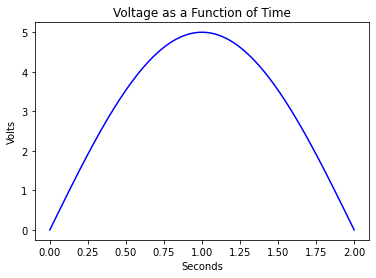

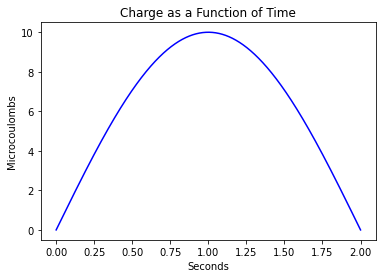

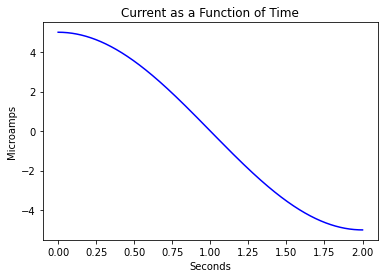

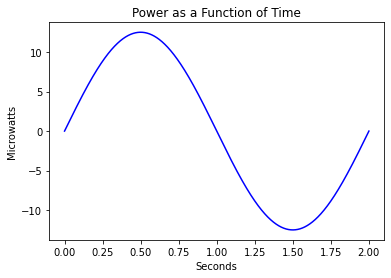

PART B


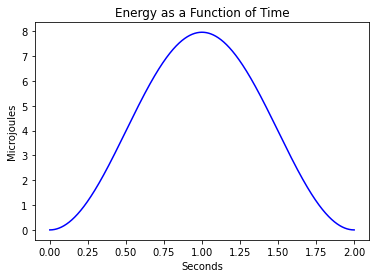

The amount of energy stored in the capacitor during the interval from 0 to 2 is: 0 microjoules


PART C
In the time interval from 0 to 1, energy is stored in the capacitor, and in the interval from 1 to 2, energy is    drained from the capicator. This is determined by when the energy function is increasing or decreasing. When the power function is increasing, energy is STORED, and when the power function is decreasing, energy is DRAINED.


In [11]:
print('PART A')
#create linspace for time interval
n = 10000
start=0
end=2
t=np.linspace(start,end,n)
#value for capacitance in microfarads
cap = 2 
#define voltage function
def voltage(t):
    v = 5*np.sin(0.5*np.pi*t)
    return v
#equation for charge
def charge(t):
    return cap *voltage(t)
#dv dt
def dvdt(t):
    return 2.5*np.cos(0.5*np.pi*t)

#equation for current
def current(t):
    return cap * dvdt(t)
    
#equation for power
def power(t):
    return voltage(t) * current(t)
#plot results 
plt.plot(t, voltage(t), 'b')
plt.ylabel('Volts')
plt.xlabel('Seconds')
plt.title("Voltage as a Function of Time")
plt.show()
plt.plot(t, charge(t), 'b')
plt.xlabel("Seconds")
plt.ylabel('Microcoulombs')
plt.title("Charge as a Function of Time")
plt.show()
plt.plot(t, current(t), 'b')
plt.ylabel('Microamps')
plt.xlabel('Seconds')
plt.title("Current as a Function of Time")
plt.show()
plt.plot(t, power(t), 'b')
plt.ylabel('Microwatts')
plt.xlabel('Seconds')
plt.title("Power as a Function of Time")
plt.show()
print('PART B')
n = 10000
energy=np.zeros(n)
for i in range (0,n):
    energy[i], err =integrate.quad(power, 0, t[i])
plt.plot(t,energy,"b")
plt.title('Energy as a Function of Time')
plt.xlabel('Seconds')
plt.ylabel('Microjoules')
plt.show()
print('The amount of energy stored in the capacitor during the interval from 0 to 2 is:',0, "microjoules")
print()
print()
print('PART C')
print('In the time interval from 0 to 1, energy is stored in the capacitor, and in the interval from 1 to 2, energy is    drained from the capicator. This is determined by when the energy function is increasing or decreasing. When the power function is increasing, energy is STORED, and when the power function is decreasing, energy is DRAINED.')



## Problem 4


#### Peamble 

The convolution of two functions is an important concept in getting information from a signal (for example, extracting frequency information from a time-domain signal). You can think of convolution as a time series of the "signal", $f(t)$, weighted by a "sampling pulse", $g(t)$, that slides along the signal, thus obtaining a result that shows what features these two functions have in common. 

You can find informative animations and an introductory presentation in Wikipedia (https://en.wikipedia.org/wiki/Convolution). Convolution has applications that include probability, statistics, computer vision, natural language processing, image and signal processing, engineering, and differential equations.

#### Statement of problem

Consider the functions $f(t)$ and $g(t)$ that represent the signal and the sampling pulse. Their convolution, denoted as $(f∗g)(t)$, is defined by the integral:

$${\displaystyle (f*g)(t)\equiv \ \int _{-\infty }^{\infty }f(\tau )g(t-\tau )\,d\tau }$$

A rectangular pulse is a function which is constant for a time interval $t\in [t_1,t_2]$ and is zero everywhere else.  Typically, a SAMPLING PULSE is also normalized, that is, the integral of $g(t)$ over all values of $t$ is equal to 1.

Calculate the convolution $(f*g)(t)$ where $f(t)$ is the signal, and it is a recatangular pulse, and $g(t)$ is the sampling function, also a rectangular pulse (choose your own parameters to generate the signal and the sampling pulses).


The area under the curve is 1, as I would expect from two rectangular pulses with area 1


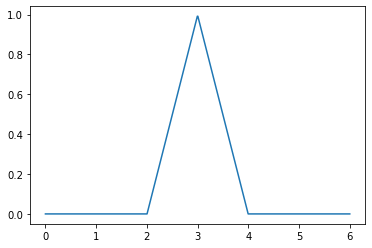

In [15]:
# from 0 to 6
tmin = 0 
tmax = 6
Nx   = 600 #so each step is 0.01
time = np.linspace(tmin,tmax,Nx)
centerf=3 #where signal pulse is centered
width=1
f=np.zeros(Nx)
#signal pulse centered at 3 with width 1 
def foft(t,center,width):
    if t < center-0.5*width:#left bound
        return 0
    elif t< center+0.5*width: #within the pulse
        return 1
    else:
        return 0 #right bound
    return f
# sliding pulse (sampling) 
g = np.zeros(Nx)
def goft(t,center,width):
    if t < center-0.5*width: #left bound
        return 0
    elif t<center+0.5*width: #within pulse
        return 1
    else:
        return 0 #right bound
    return g
dt=time[1]-time[0] #find value for dt
convolution=np.zeros(Nx) # initialize 
for P in range(Nx): # time loop
    prod = 0 #initalize product
    for S in range(Nx): #tau loop
        f[S]= foft(time[S],centerf,width)# center is always at centerf, same pulse everytime
        g[S]=goft(time[S],time[P],width)#center is shifting with time (0->6) calculated in P loop
    convolution[P]=np.sum(f*g)*dt #calculate all index values,then sum product of f and g and multiplying by dt 
print("The area under the curve is 1, as I would expect from two rectangular pulses with area 1")
plt.plot(time,convolution)
plt.show()